# **Objetivo**

**Base**: None

**Objetivo**: Entrenar un primer modelo de prediccion y compararlo contra un standard (aleatorio)

**Metodo**: Entrenar un modelo XGB, entrenar un modelo aleatorio y luego comparar las performances

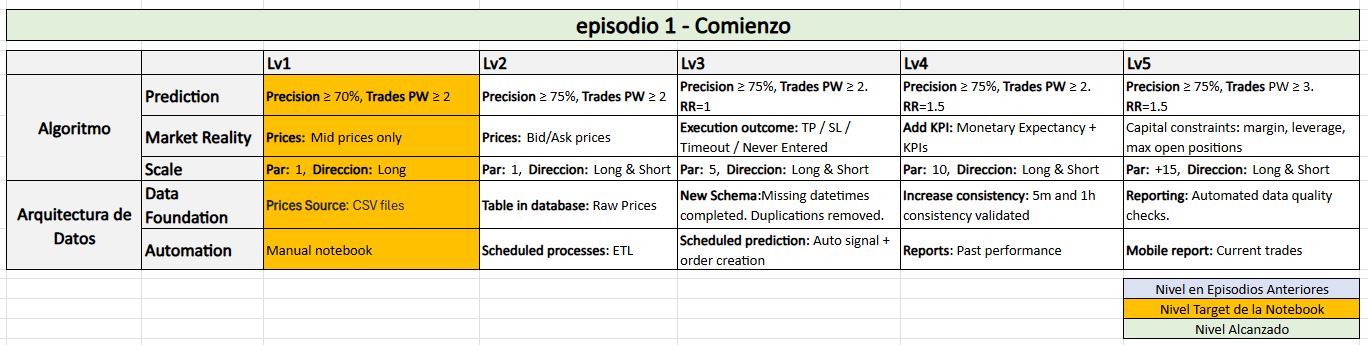

# **1 - Importo Dependencias**

In [ ]:
pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=5ef03e08dbfbae7c7670bfa0721ef59c44da921c1afea835f4d5b179209df8b3
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
# importamos las librerias
from sklearn.model_selection import train_test_split
from ta.trend import EMAIndicator
import os, joblib
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# classes
class RandomModel:
    def fit(self, X, y):
        pass

    def predict_proba(self, X):
        probs = np.random.rand(len(X))
        return np.column_stack([1 - probs, probs])

ramdom = RandomModel()

# **2 - Defino Parametros**

In [ ]:
direction = 'long'
lookahead_hours = 5
target_points = 100
point_size = 0.00001
currency = 'EURUSD'

# **3 - Importo Dataset**

In [ ]:
df = pd.read_csv('EURUSD.csv')
print(f"Successfully loaded {len(df)} rows from EURUSD.csv")
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
display(df.head())

Successfully loaded 33276 rows from EURUSD.csv


,Open_EURUSD,High_EURUSD,Low_EURUSD,Close_EURUSD,Volume_EURUSD
Datetime,,,,,
2021-01-03 22:00:00,1.22400,1.22427,1.22324,1.22342,184
2021-01-03 23:00:00,1.22339,1.22528,1.22310,1.22500,1623
2021-01-04 00:00:00,1.22498,1.22498,1.22388,1.22409,2930
2021-01-04 01:00:00,1.22410,1.22558,1.22400,1.22527,3149
2021-01-04 02:00:00,1.22526,1.22586,1.22496,1.22542,2640


# **4 - Preparo los Inputs (o Variables de Entrada)**

In [ ]:
# 2 - Preparacion: CatBoost no necesita normalizacion
X = df.copy()
X = X[['Close_EURUSD','Open_EURUSD','High_EURUSD','Low_EURUSD','Volume_EURUSD']]
X[['Close_EURUSD','Open_EURUSD','High_EURUSD','Low_EURUSD']] = X[['Close_EURUSD','Open_EURUSD','High_EURUSD','Low_EURUSD']]
X['Volume_EURUSD'] = X['Volume_EURUSD']

X['Hour'] = X.index.hour
X['Day_of_Week'] = X.index.dayofweek    # Monday=0

X['EMA_9'] = EMAIndicator(close=X['Close_EURUSD'], window=9).ema_indicator()
X['EMA_20'] = EMAIndicator(close=X['Close_EURUSD'], window=20).ema_indicator()
X['EMA_50'] = EMAIndicator(close=X['Close_EURUSD'], window=50).ema_indicator()
X['EMA_100'] = EMAIndicator(close=X['Close_EURUSD'], window=100).ema_indicator()
X['EMA_200'] = EMAIndicator(close=X['Close_EURUSD'], window=200).ema_indicator()
X = X.iloc[200-1:]

# **5 - Defino Output (o Variable Objetivo)**

In [ ]:
# copy of X
X_ready = X.copy()

# defino minimo movimiento relevante de target
target_move = target_points * point_size

# Column datetime to datime type and convert to index
if direction == "long":
    future_max = (
        X_ready['High_EURUSD']
        .shift(-1)
        .rolling(window=lookahead_hours)
        .max()
        .shift(-(lookahead_hours - 1))
    )
    X_ready['y'] = (future_max >= X_ready['Close_EURUSD'] + target_move).astype(int)

elif direction == "short":
    future_min = (
        X_ready['Low_EURUSD']
        .shift(-1)
        .rolling(window=lookahead_hours)
        .min()
        .shift(-(lookahead_hours - 1))
    )
    X_ready['y'] = (future_min <= X_ready['Close_EURUSD'] - target_move).astype(int)

X_ready = X_ready.iloc[:-lookahead_hours]

# Distribucion balanceada?
print(X_ready['y'].value_counts(normalize=True))

# definition
target_move = target_points * point_size

# Fill NaN values in 'Volume_EURUSD' with 0 before converting to int
X_ready['Volume_EURUSD'] = X_ready['Volume_EURUSD'].fillna(0)

# Convert 'Volume_EURUSD' column to integer type
X_ready['Volume_EURUSD'] = X_ready['Volume_EURUSD'].astype(int)

# y
X_ready['y'].head(5)

y
1    0.542544
0    0.457456
Name: proportion, dtype: float64


,y
Datetime,
2021-01-14 05:00:00,1
2021-01-14 06:00:00,1
2021-01-14 07:00:00,1
2021-01-14 08:00:00,0
2021-01-14 09:00:00,0


# **6 - Defino & Entreno los Modelos**

In [ ]:
from xgboost import XGBClassifier
np.random.seed(27)
models = [
   (XGBClassifier(n_estimators=500,
                  max_depth=6,
                  learning_rate=0.05,
                  random_state=0), "XGB (500 trees)"),
   (RandomModel(), "Random Model")
]

In [ ]:
results = []
thresholds = [0.55, 0.575, 0.6, 0.625, 0.65, 0.675, 0.7, 0.725, 0.75, 0.775, 0.8]

results = [] # Clear the results list before running the training loop
for model, model_name in models:
    print(f'Training {model_name}')

    X_ready = X_ready.sort_index()
    df = X_ready.drop(columns=['y'])
    y = X_ready['y']

    # Split (time-based)
    x_train, x_val, y_train, y_val = train_test_split(df, y, test_size=0.2, shuffle=False)

    # Train
    model.fit(x_train, y_train)

    # Probabilities
    y_prob_train = model.predict_proba(x_train)[:, 1]
    y_prob_val   = model.predict_proba(x_val)[:, 1]

    for threshold in thresholds:
        # Thresholded predictions
        y_pred_train = (y_prob_train > threshold).astype(int)
        y_pred_val   = (y_prob_val > threshold).astype(int)
        n_trades_val = y_pred_val.sum()

        # Metrics
        row = {
            "model": model_name,
            "threshold":threshold,
            "n_trades_val":n_trades_val,

            # Class 1 focus (important)
            "val_precision_1": precision_score(y_val, y_pred_val, pos_label=1, zero_division=0),
            "val_recall_1": recall_score(y_val, y_pred_val, pos_label=1),
            "val_f1_1": f1_score(y_val, y_pred_val, pos_label=1)
        }

        results.append(row)

    # Save model
    os.makedirs(f"models/{direction}", exist_ok=True)
    filename = f"models/{direction}/{model_name}_{currency}.pkl"
    joblib.dump(model, filename)


results_df = pd.DataFrame(results).sort_values(by="val_precision_1", ascending=False)
results_df.head()

Training XGB (500 trees)
Training Random Model


,model,threshold,n_trades_val,val_precision_1,val_recall_1,val_f1_1
9,XGB (500 trees),0.775,278,0.726619,0.053766,0.100124
8,XGB (500 trees),0.750,422,0.715640,0.080383,0.144532
10,XGB (500 trees),0.800,172,0.715116,0.032739,0.062611
6,XGB (500 trees),0.700,839,0.692491,0.154645,0.252829
7,XGB (500 trees),0.725,598,0.692308,0.110194,0.190126


# **7 - Analizo Resultados**

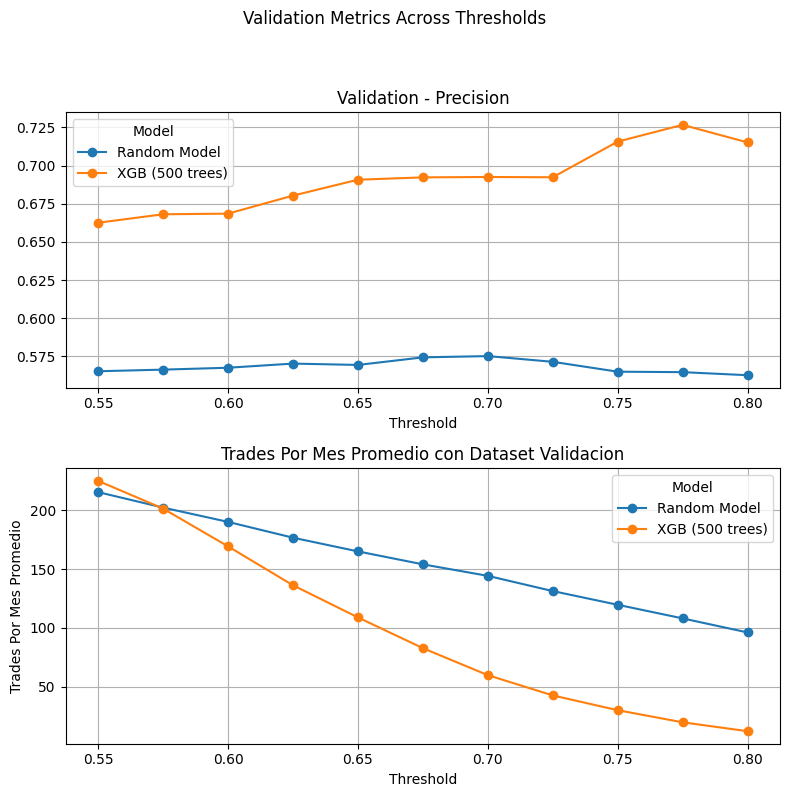

In [ ]:
# Determine the duration of the validation period in months dynamically
min_date_val = x_val.index.min().to_period('M')
max_date_val = x_val.index.max().to_period('M')
num_val_months = (max_date_val - min_date_val).n + 1
results_df['n_trades_val_per_month'] = results_df['n_trades_val'] / num_val_months

validation_metrics = [
    ("val_precision_1", "Validation - Precision"),
    ("n_trades_val_per_month", "Trades Por Mes Promedio con Dataset Validacion")
]

# Create a figure for validation plots
fig_val, axes_val = plt.subplots(2, 1, figsize=(8, 8))

for i, (metric, title) in enumerate(validation_metrics):
    ax = axes_val[i]
    pivot_val = results_df.pivot(
        index="threshold",
        columns="model",
        values=metric
    )
    pivot_val.plot(marker="o", ax=ax)
    ax.set_title(title)
    ax.grid()
    ax.set_xlabel("Threshold")
    if metric == "n_trades_val_per_month":
        ax.set_ylabel("Trades Por Mes Promedio")
    ax.legend(title='Model')

plt.suptitle('Validation Metrics Across Thresholds', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# **Resultados**

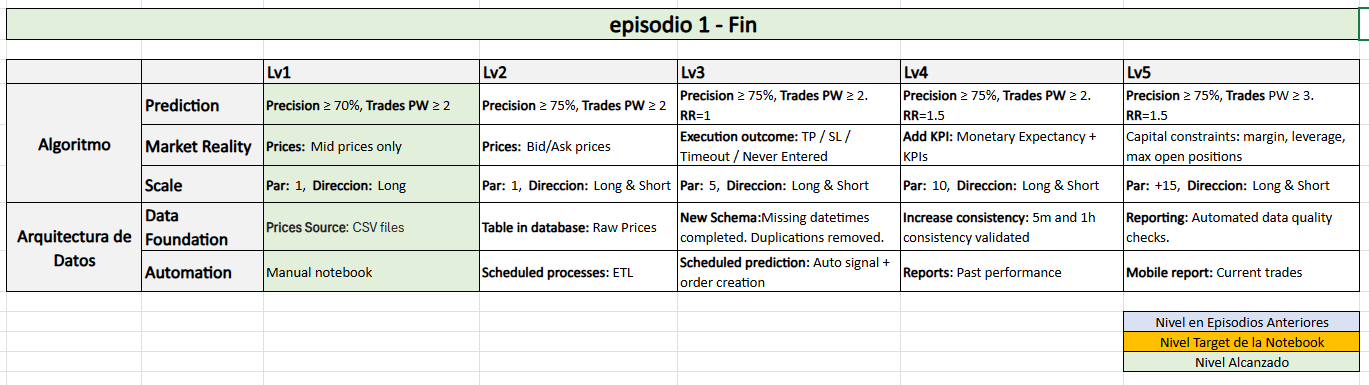